<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/%22Comparative_Analysis_of_Machine_Learning_Techniques_for_Peak_Load_Forecasting_in_Regional_Grids_Using_Weather_and_Calendar_Features%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Hybrid Explainable AI Framework for Electricity Load Forecasting Using XGBoost, Residual Analysis, and Post-Hoc Explainability with LIME and SHAP


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main file
df = pd.read_csv('/content/drive/MyDrive/Dataset/continuous dataset.csv')   # Change name if different

print("Shape of data:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().sum())

Shape of data: (48048, 17)

First 5 rows:
              datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
0  2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174  21.850546   
1  2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418  22.166944   
2  2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480  22.454911   
3  2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273  22.110481   
4  2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281  21.186089   

     T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  QV2M_dav   TQL_dav  \
0  23.482446  0.017272  0.001855  10.328949  22.662134  0.016562  0.096100   
1  23.399255  0.017265  0.001327  10.681517  22.578943  0.016509  0.087646   
2  23.343530  0.017211  0.001428  10.874924  22.531030  0.016479  0.078735   
3  23.238794  0.017128  0.002599  10.518620  22.512231  0.016487  0.068390   
4  23.075403  0.017059  0.001729   9.733589  22.481653  0.016456  0.064362   

    W2M_

In [ ]:
import pandas as pd
import numpy as np

# ====================== STEP 2 ======================
# Load the data again (safe way)
df = pd.read_csv('/content/drive/MyDrive/Dataset/continuous dataset.csv')

# 1. Convert datetime column properly
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. Create important time features
df['hour'] = df['datetime'].dt.hour                    # 0 to 23
df['dayofweek'] = df['datetime'].dt.dayofweek          # 0=Monday, 6=Sunday
df['month'] = df['datetime'].dt.month                  # 1 to 12
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)   # 1=weekend, 0=weekday

# 3. Use the holiday column already available
df['is_holiday'] = df['holiday']                       # already 0 or 1

# 4. Create lag features (very important for load forecasting)
df['lag_1']   = df['nat_demand'].shift(1)     # previous hour load
df['lag_24']  = df['nat_demand'].shift(24)    # same hour yesterday
df['lag_168'] = df['nat_demand'].shift(168)   # same hour last week

# 5. Simple rolling average (last 24 hours average load)
df['rolling_mean_24'] = df['nat_demand'].rolling(window=24).mean()

# 6. Drop rows that have missing values (because of lags)
df = df.dropna().reset_index(drop=True)

# ====================== Check Results ======================
print("✅ Step 2 Completed!")
print("Shape after cleaning:", df.shape)
print("\nNew columns created:")
print(df.columns.tolist())

print("\nFirst 5 rows of important columns:")
print(df[['datetime', 'nat_demand', 'hour', 'dayofweek', 'is_weekend',
          'is_holiday', 'lag_1', 'lag_24', 'lag_168']].head())

print("\nMissing values now:", df.isnull().sum().sum())

✅ Step 2 Completed!
Shape after cleaning: (47880, 26)

New columns created:
['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24']

First 5 rows of important columns:
             datetime  nat_demand  hour  dayofweek  is_weekend  is_holiday  \
0 2015-01-10 01:00:00    906.9580     1          5           1           0   
1 2015-01-10 02:00:00    863.5135     2          5           1           0   
2 2015-01-10 03:00:00    848.4447     3          5           1           0   
3 2015-01-10 04:00:00    839.8821     4          5           1           0   
4 2015-01-10 05:00:00    847.1073     5          5           1           0   

      lag_1    lag_24   lag_168  
0  949.5031  943.6081  970.3450  
1  906.9580  917.0640  912.1755  
2  863.5135  

In [ ]:
# ====================== STEP 3 ======================

# Define Peak Hours (Top 10% highest demand)
peak_threshold = df['nat_demand'].quantile(0.90)
df['is_peak'] = (df['nat_demand'] > peak_threshold).astype(int)

print("Peak threshold (90th percentile):", round(peak_threshold, 2), "MWh")
print("Total peak hours in dataset:", df['is_peak'].sum())
print("Percentage of peak hours:", round(df['is_peak'].mean()*100, 2), "%\n")

# ====================== Select Features ======================
feature_columns = [
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday',
    'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24',
    'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',     # Tocumen weather
    'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san',     # Santiago weather
    'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav'      # David weather
]

X = df[feature_columns]
y = df['nat_demand']

print("Number of features used:", len(feature_columns))
print("Feature columns:")
print(feature_columns)

# ====================== Time-based Train-Test Split ======================
# We use 80% for training, last 20% for testing (chronological)
train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("\n✅ Train-Test Split Done!")
print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))
print("Test period starts from:", df['datetime'].iloc[train_size])

# Optional: Also create peak mask for test set
peak_test_mask = df['is_peak'].iloc[train_size:].values

Peak threshold (90th percentile): 1461.23 MWh
Total peak hours in dataset: 4788
Percentage of peak hours: 10.0 %

Number of features used: 21
Feature columns:
['hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'lag_1', 'lag_24', 'lag_168', 'rolling_mean_24', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav']

✅ Train-Test Split Done!
Training samples : 38304
Testing samples  : 9576
Test period starts from: 2019-05-25 01:00:00


In [ ]:
# ====================== STEP 4 (FINAL FIXED) ======================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

results = []

for name, model in models.items():
    print(f"\n🔹 Training {name}...")

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    # -------- Normal Metrics --------
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

    # -------- Peak Metrics (FIXED) --------
    peak_mask_bool = peak_test_mask.astype(bool)

    y_test_peak = y_test.iloc[peak_mask_bool]
    pred_peak = pred[peak_mask_bool]

    peak_mape = np.mean(np.abs((y_test_peak - pred_peak) / y_test_peak)) * 100

    results.append([name, mae, rmse, mape, peak_mape])

    print(f"{name} Results:")
    print(f"MAE       : {mae:.2f}")
    print(f"RMSE      : {rmse:.2f}")
    print(f"MAPE      : {mape:.2f}%")
    print(f"Peak MAPE : {peak_mape:.2f}%")

results_df = pd.DataFrame(results, columns=[
    'Model', 'MAE', 'RMSE', 'MAPE (%)', 'Peak MAPE (%)'
])

print("\n✅ Final Comparison Table:")
print(results_df.sort_values(by='MAPE (%)'))


🔹 Training Linear Regression...
Linear Regression Results:
MAE       : 34.03
RMSE      : 44.00
MAPE      : 2.81%
Peak MAPE : 2.52%

🔹 Training Random Forest...
Random Forest Results:
MAE       : 19.23
RMSE      : 27.10
MAPE      : 1.61%
Peak MAPE : 1.34%

🔹 Training XGBoost...
XGBoost Results:
MAE       : 18.50
RMSE      : 25.67
MAPE      : 1.55%
Peak MAPE : 1.34%

🔹 Training SVR...
SVR Results:
MAE       : 37.87
RMSE      : 51.49
MAPE      : 3.07%
Peak MAPE : 3.69%

🔹 Training KNN...
KNN Results:
MAE       : 31.89
RMSE      : 44.48
MAPE      : 2.65%
Peak MAPE : 2.32%

✅ Final Comparison Table:
               Model        MAE       RMSE  MAPE (%)  Peak MAPE (%)
2            XGBoost  18.495798  25.666189  1.545016       1.336264
1      Random Forest  19.226893  27.100334  1.609147       1.342798
4                KNN  31.893926  44.479126  2.648169       2.323631
0  Linear Regression  34.027247  43.996448  2.814463       2.522167
3                SVR  37.870561  51.486976  3.072001     

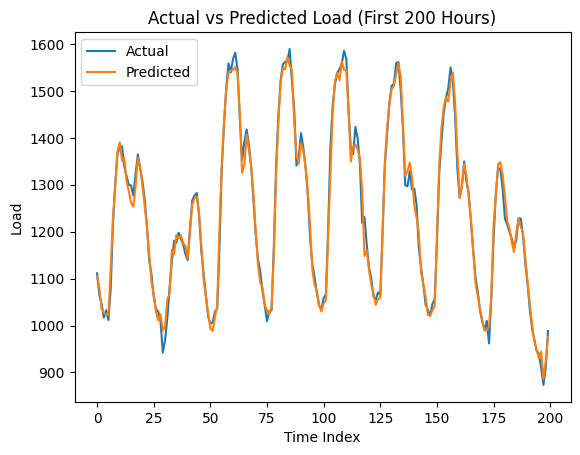

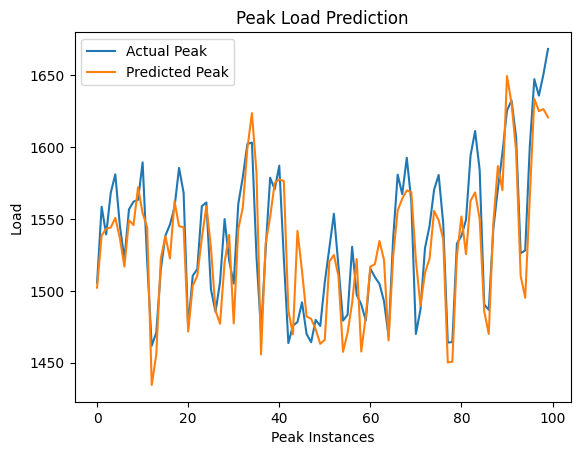

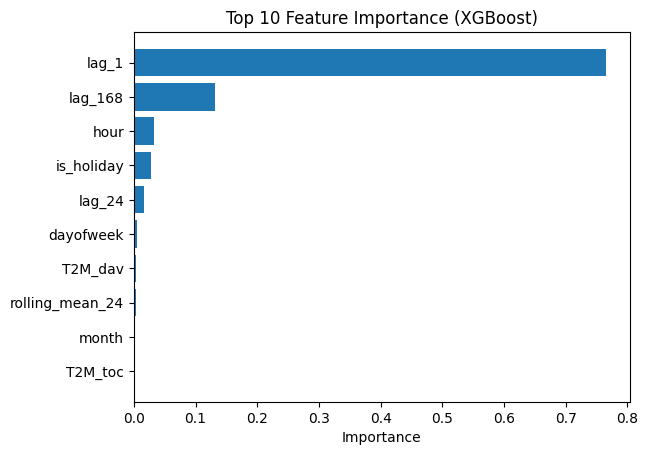

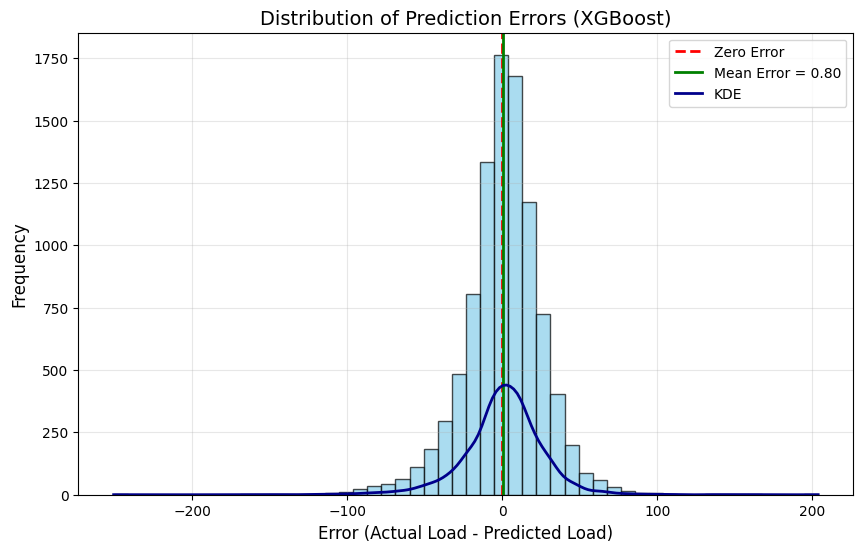

In [ ]:
# ====================== STEP 5 ======================

import matplotlib.pyplot as plt
import numpy as np

# Use best model (XGBoost)
best_model = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
best_model.fit(X_train, y_train)

# Predictions
y_pred = best_model.predict(X_test)

# ====================== 1. Actual vs Predicted ======================
plt.figure()
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.title('Actual vs Predicted Load (First 200 Hours)')
plt.xlabel('Time Index')
plt.ylabel('Load')
plt.legend()
plt.show()

# ====================== 2. Peak-only Plot ======================
peak_mask_bool = peak_test_mask.astype(bool)

plt.figure()
plt.plot(y_test.iloc[peak_mask_bool].values[:100], label='Actual Peak')
plt.plot(y_pred[peak_mask_bool][:100], label='Predicted Peak')
plt.title('Peak Load Prediction')
plt.xlabel('Peak Instances')
plt.ylabel('Load')
plt.legend()
plt.show()

# ====================== 3. Feature Importance ======================
importances = best_model.feature_importances_
features = X_train.columns

# Sort
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.show()

# ====================== 4. Error Distribution ======================
errors = y_test.values - y_pred

plt.figure(figsize=(10, 6))

# Histogram
plt.hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=False)

# Add mean and zero lines
mean_error = np.mean(errors)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(x=mean_error, color='green', linestyle='-', linewidth=2, label=f'Mean Error = {mean_error:.2f}')

plt.title('Distribution of Prediction Errors (XGBoost)', fontsize=14)
plt.xlabel('Error (Actual Load - Predicted Load)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Optional: Add KDE curve for smoother view
from scipy.stats import gaussian_kde
kde = gaussian_kde(errors)
x_range = np.linspace(errors.min(), errors.max(), 200)
plt.plot(x_range, kde(x_range) * len(errors) * (x_range[1]-x_range[0]),
         color='darkblue', linewidth=2, label='KDE')

plt.legend()
plt.show()

In [36]:
!pip install shap

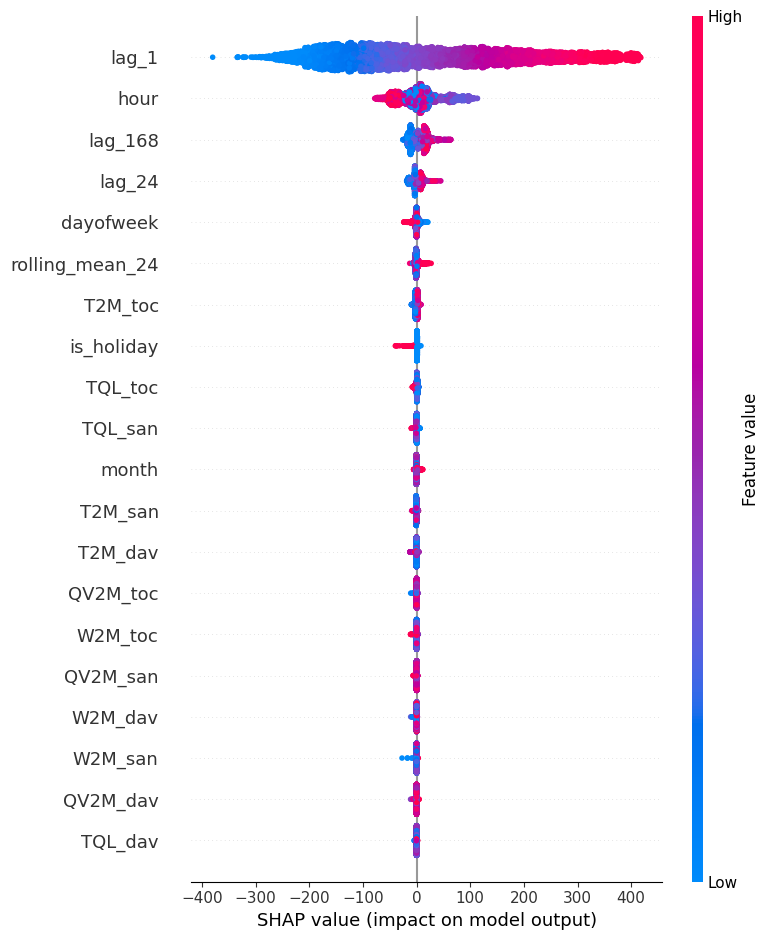

In [35]:
#SHAP Explainability
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (global importance)
shap.summary_plot(shap_values, X_test)

In [27]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=26c4cc85ab95e5180a6f400d7680b954100e991c7978072d8bca86820700117b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [28]:
# ====================== LIME EXPLANATIONS ======================
import lime
import lime.lime_tabular

# Create the LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,          # Must be numpy array
    feature_names=X_train.columns.tolist(),
    mode='regression',                     # Important: regression mode
    verbose=False,
    random_state=42
)

# Choose a few interesting instances to explain
# Example 1: A high peak load instance
idx_peak = y_test.nlargest(1).index[0]        # Highest actual load
instance_peak = X_test.loc[idx_peak].values

# Example 2: A random / median instance
idx_random = y_test.index[len(y_test)//2]
instance_random = X_test.loc[idx_random].values

print(f"Explaining instance {idx_peak} (High Load)")
print(f"Actual Load : {y_test.loc[idx_peak]:.2f}")
print(f"Predicted Load: {best_model.predict([instance_peak])[0]:.2f}\n")

Explaining instance 44005 (High Load)
Actual Load : 1754.88
Predicted Load: 1657.92



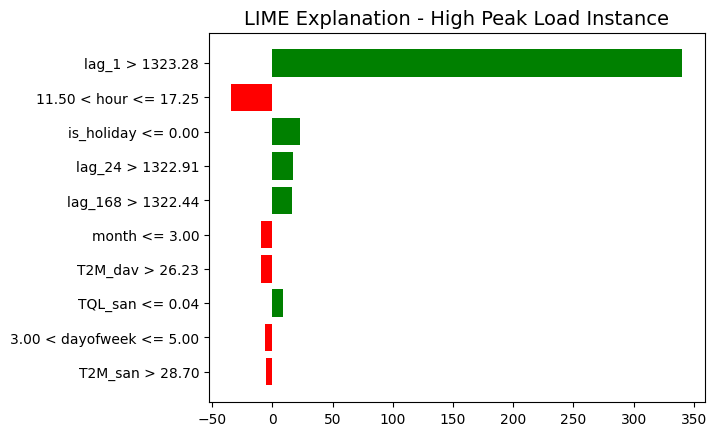

In [29]:
# ====================== LIME Plot - High Load Instance ======================
exp_peak = explainer.explain_instance(
    instance_peak,
    best_model.predict,
    num_features=10
)

# Show plot
fig = exp_peak.as_pyplot_figure()
plt.title('LIME Explanation - High Peak Load Instance', fontsize=14)
plt.show()



Explaining instance 43092 (Typical Load)


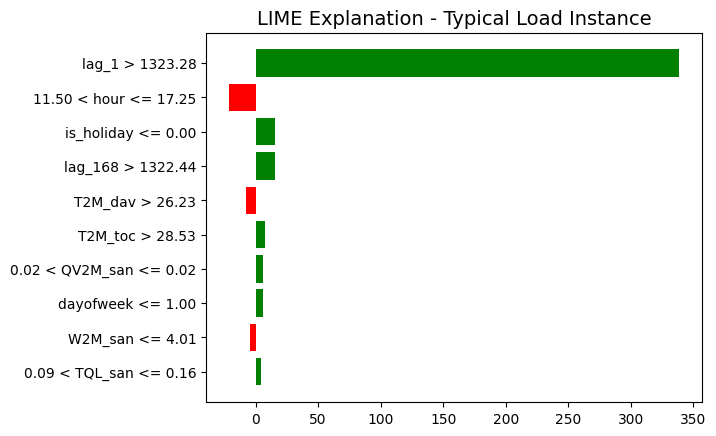

In [30]:
print(f"Explaining instance {idx_random} (Typical Load)")
exp_random = explainer.explain_instance(
    instance_random,
    best_model.predict,
    num_features=10
)

fig = exp_random.as_pyplot_figure()
plt.title('LIME Explanation - Typical Load Instance', fontsize=14)
plt.show()

In [31]:
# Print top contributing features
print("\n=== Top Features Contributing to Prediction ===")
for feat, weight in exp_peak.as_list():
    print(f"{feat:40} : {weight:+.4f}")


=== Top Features Contributing to Prediction ===
lag_1 > 1323.28                          : +340.4133
11.50 < hour <= 17.25                    : -34.1398
is_holiday <= 0.00                       : +22.6879
lag_24 > 1322.91                         : +17.0396
lag_168 > 1322.44                        : +15.9810
month <= 3.00                            : -9.5470
T2M_dav > 26.23                          : -9.4017
TQL_san <= 0.04                          : +8.3193
3.00 < dayofweek <= 5.00                 : -6.1545
T2M_san > 28.70                          : -5.0314



Explaining High Load Instance (Index: 44005)
Actual Load : 1754.88
Predicted Load: 1657.92
Error: 96.96


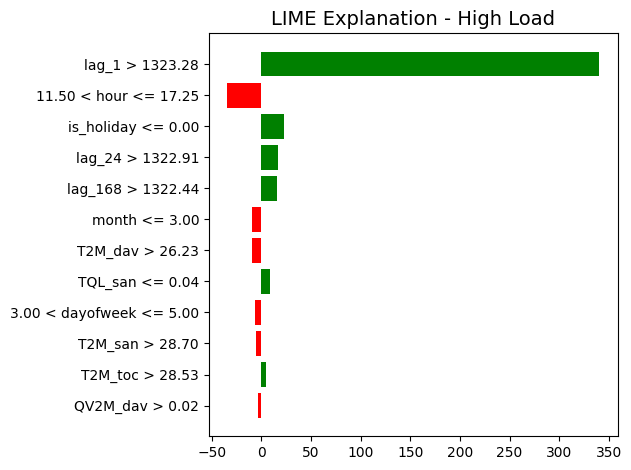


Top 8 Contributing Features:
lag_1 > 1323.28                               → +340.4596
11.50 < hour <= 17.25                         → -34.1339
is_holiday <= 0.00                            → +22.5370
lag_24 > 1322.91                              → +17.0400
lag_168 > 1322.44                             → +15.9492
month <= 3.00                                 → -9.6475
T2M_dav > 26.23                               → -9.3692
TQL_san <= 0.04                               → +8.3188

Explaining Low Load Instance (Index: 41881)
Actual Load : 816.35
Predicted Load: 881.16
Error: -64.81


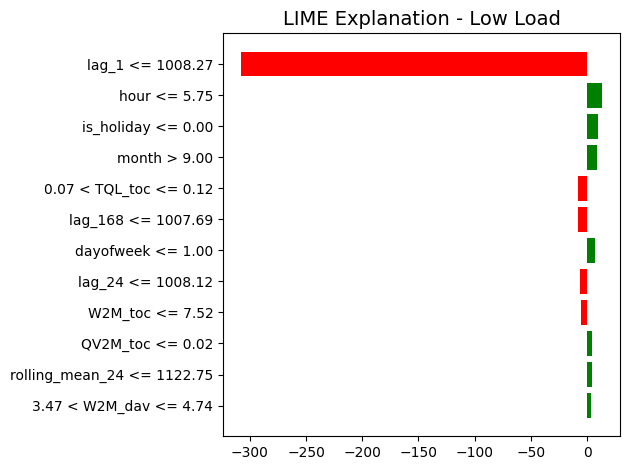


Top 8 Contributing Features:
lag_1 <= 1008.27                              → -307.8623
hour <= 5.75                                  → +13.2634
is_holiday <= 0.00                            → +10.0332
month > 9.00                                  → +8.4339
0.07 < TQL_toc <= 0.12                        → -8.3032
lag_168 <= 1007.69                            → -7.7117
dayofweek <= 1.00                             → +7.3206
lag_24 <= 1008.12                             → -6.3521

Explaining Average Load Instance (Index: 43092)
Actual Load : 1704.82
Predicted Load: 1661.91
Error: 42.91


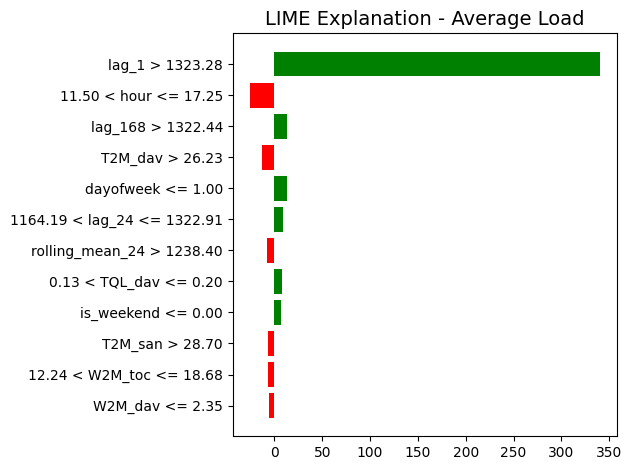


Top 8 Contributing Features:
lag_1 > 1323.28                               → +339.9589
11.50 < hour <= 17.25                         → -25.3858
lag_168 > 1322.44                             → +13.4298
T2M_dav > 26.23                               → -13.1746
dayofweek <= 1.00                             → +12.9889
1164.19 < lag_24 <= 1322.91                   → +9.3627
rolling_mean_24 > 1238.40                     → -8.0585
0.13 < TQL_dav <= 0.20                        → +7.7510


In [32]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# ====================== LIME Explainer Setup ======================
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    verbose=False,
    random_state=42
)

# ====================== Select 3 Contrasting Instances ======================
# 1. High Load (Peak)
idx_high = y_test.nlargest(1).index[0]

# 2. Low Load
idx_low = y_test.nsmallest(1).index[0]

# 3. Average / Median Load
idx_avg = y_test.index[len(y_test)//2]

instances = {
    'High Load': (idx_high, X_test.loc[idx_high].values, y_test.loc[idx_high]),
    'Low Load':  (idx_low,  X_test.loc[idx_low].values,  y_test.loc[idx_low]),
    'Average Load': (idx_avg, X_test.loc[idx_avg].values, y_test.loc[idx_avg])
}

# ====================== Generate LIME Explanations ======================
lime_explanations = {}

for name, (idx, instance, actual) in instances.items():
    print(f"\n{'='*60}")
    print(f"Explaining {name} Instance (Index: {idx})")
    print(f"Actual Load : {actual:.2f}")

    pred = best_model.predict([instance])[0]
    print(f"Predicted Load: {pred:.2f}")
    print(f"Error: {actual - pred:.2f}")

    # Explain instance
    exp = explainer.explain_instance(
        instance,
        best_model.predict,
        num_features=12
    )
    lime_explanations[name] = exp

    # Show Plot
    fig = exp.as_pyplot_figure()
    plt.title(f'LIME Explanation - {name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Text Summary (Good for paper)
    print("\nTop 8 Contributing Features:")
    for feat, weight in exp.as_list()[:8]:
        print(f"{feat:45} → {weight:+.4f}")

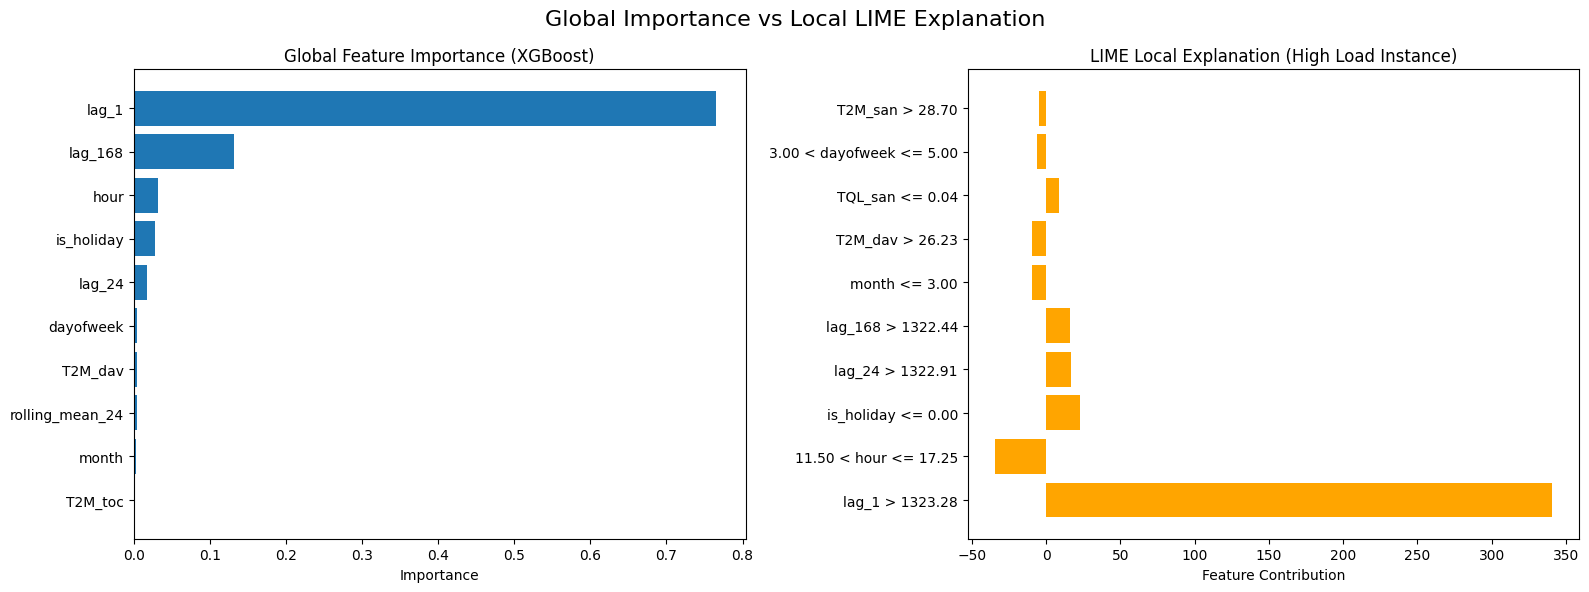

In [33]:
# ====================== Global vs Local Comparison ======================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global Feature Importance (XGBoost)
importances = best_model.feature_importances_
top_idx = np.argsort(importances)[-10:]
axes[0].barh(range(10), importances[top_idx])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([X_train.columns[i] for i in top_idx])
axes[0].set_title('Global Feature Importance (XGBoost)')
axes[0].set_xlabel('Importance')

# LIME for High Load (as example)
exp = lime_explanations['High Load']
feat_names = []
weights = []
for feat, w in exp.as_list()[:10]:
    feat_names.append(feat[:35])   # truncate long names
    weights.append(w)

axes[1].barh(range(len(weights)), weights, color='orange')
axes[1].set_yticks(range(len(weights)))
axes[1].set_yticklabels(feat_names)
axes[1].set_title('LIME Local Explanation (High Load Instance)')
axes[1].set_xlabel('Feature Contribution')

plt.suptitle('Global Importance vs Local LIME Explanation', fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# ====================== 1. LIME Explainer ======================
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    random_state=42
)

# ====================== 2. SHAP Explainer ======================
shap_explainer = shap.TreeExplainer(best_model)

# Use a sample for speed
X_test_sample = X_test.iloc[:500]
shap_values = shap_explainer.shap_values(X_test_sample)

print("✅ Both LIME and SHAP explainers ready!\n")

✅ Both LIME and SHAP explainers ready!




COMPARISON → High Load Instance
Actual Load    : 1754.88
Predicted Load : 1657.92


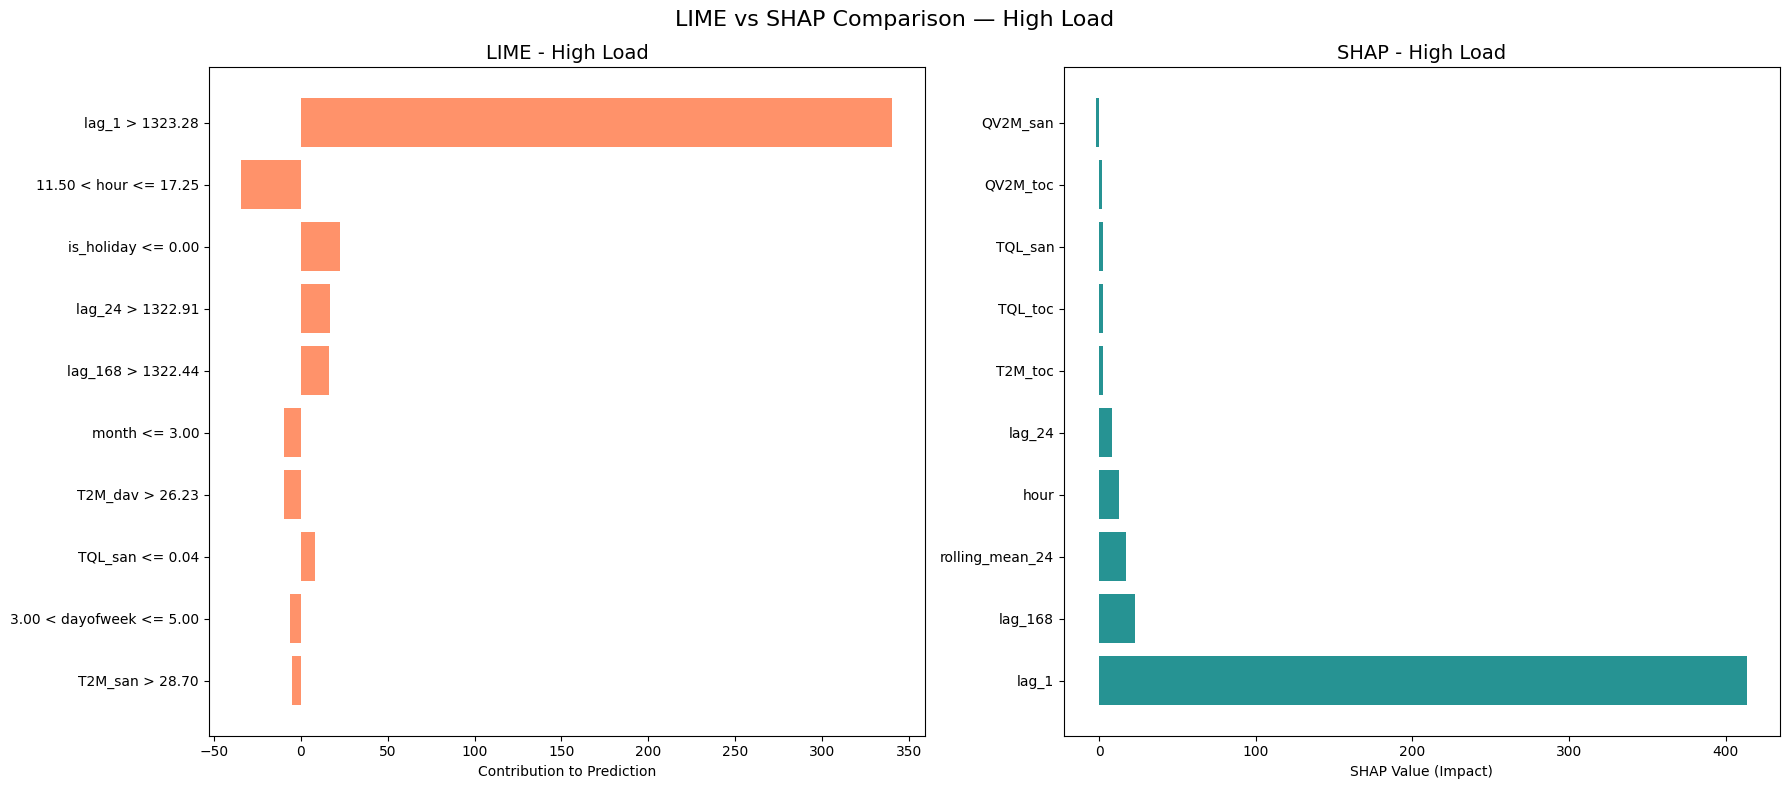


Top Features Comparison:
Rank LIME Feature                             LIME       SHAP Feature                             SHAP      
----------------------------------------------------------------------------------------------------
1   lag_1 > 1323.28                          +340.413   lag_1                                    +413.953
2   11.50 < hour <= 17.25                     -34.140   lag_168                                   +23.052
3   is_holiday <= 0.00                        +22.688   rolling_mean_24                           +17.260
4   lag_24 > 1322.91                          +17.040   hour                                      +12.811
5   lag_168 > 1322.44                         +15.981   lag_24                                     +7.802

COMPARISON → Low Load Instance
Actual Load    : 816.35
Predicted Load : 881.16


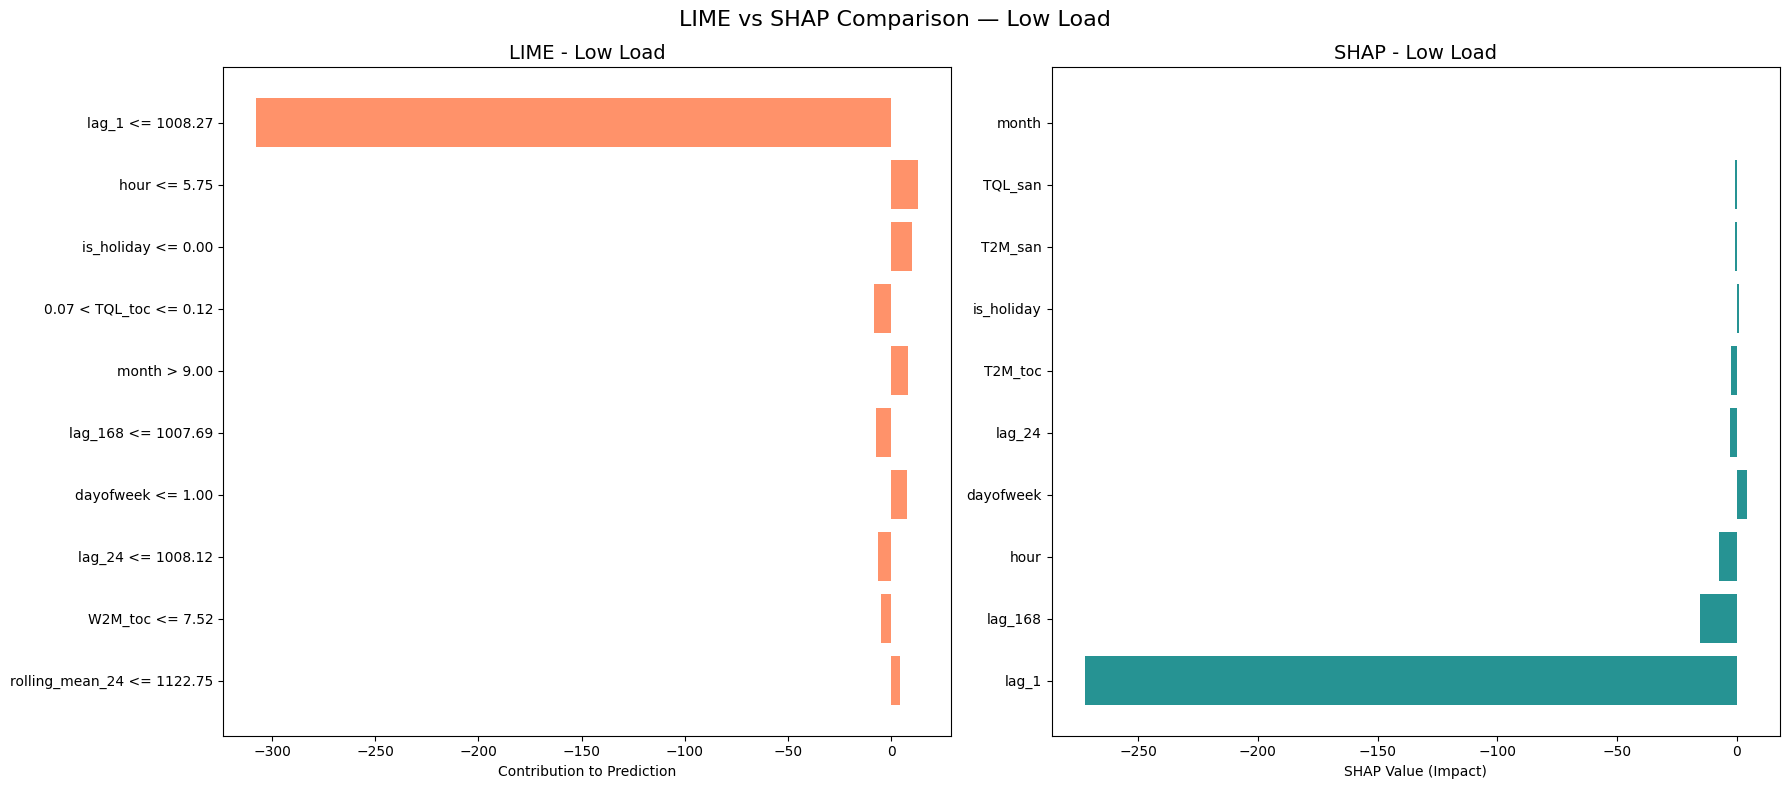


Top Features Comparison:
Rank LIME Feature                             LIME       SHAP Feature                             SHAP      
----------------------------------------------------------------------------------------------------
1   lag_1 <= 1008.27                         -307.766   lag_1                                    -272.365
2   hour <= 5.75                              +13.107   lag_168                                   -15.188
3   is_holiday <= 0.00                         +9.834   hour                                       -7.464
4   0.07 < TQL_toc <= 0.12                     -8.293   dayofweek                                  +4.302
5   month > 9.00                               +8.244   lag_24                                     -2.788

COMPARISON → Average Load Instance
Actual Load    : 1704.82
Predicted Load : 1661.91


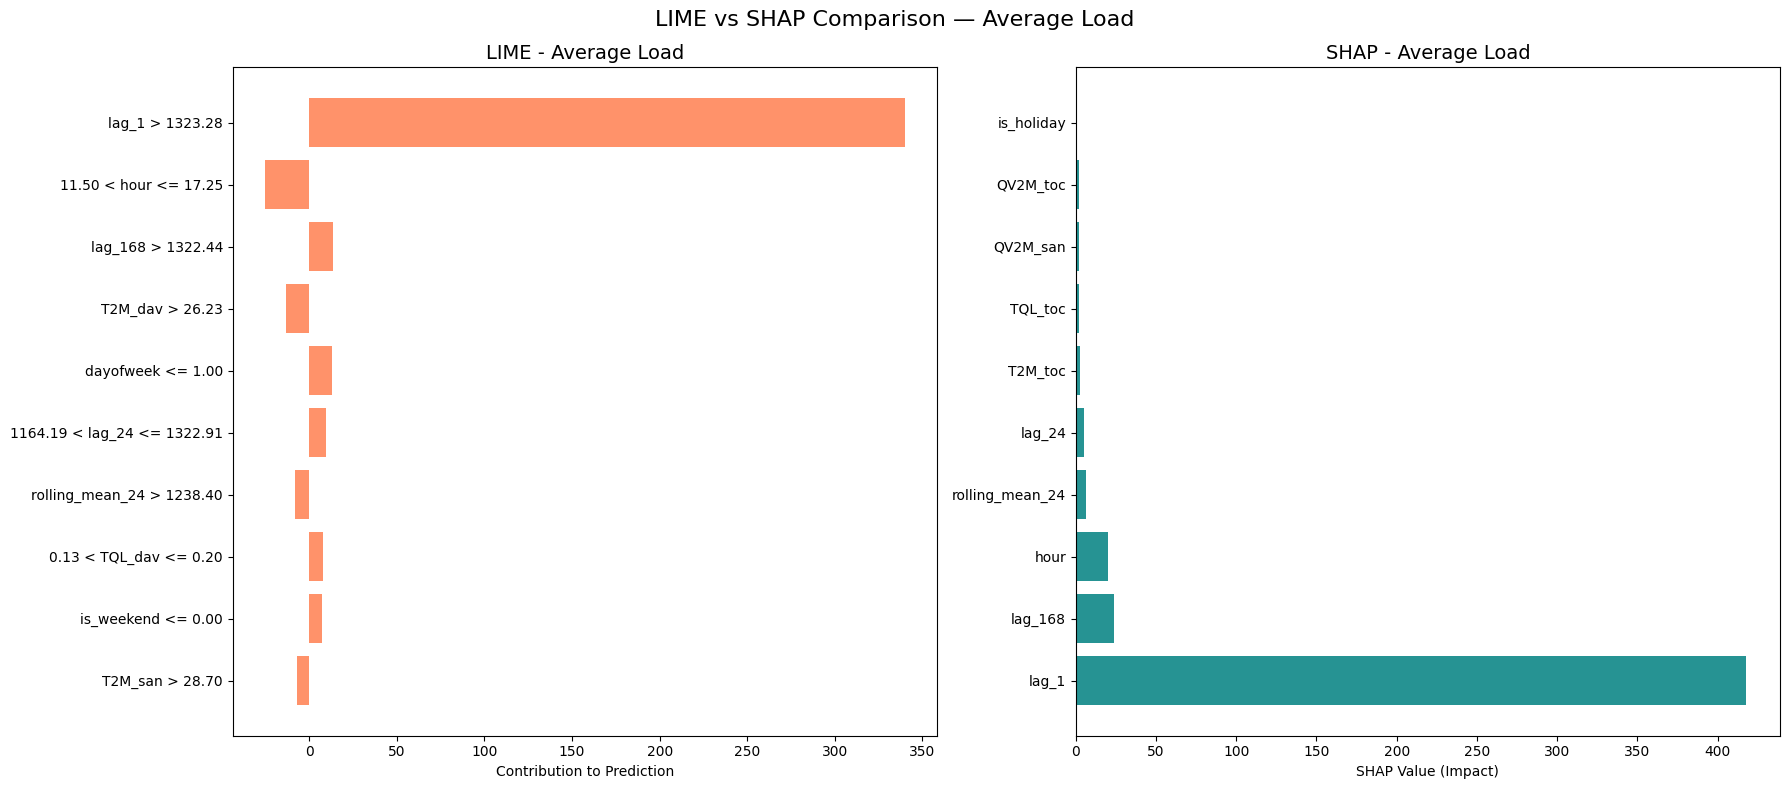


Top Features Comparison:
Rank LIME Feature                             LIME       SHAP Feature                             SHAP      
----------------------------------------------------------------------------------------------------
1   lag_1 > 1323.28                          +339.966   lag_1                                    +418.008
2   11.50 < hour <= 17.25                     -25.450   lag_168                                   +23.952
3   lag_168 > 1322.44                         +13.546   hour                                      +20.167
4   T2M_dav > 26.23                           -13.273   rolling_mean_24                            +6.073
5   dayofweek <= 1.00                         +12.796   lag_24                                     +5.282


In [40]:
# ====================== 3. Side-by-Side LIME vs SHAP ======================

for name, (idx, instance, actual) in instances.items():
    print(f"\n{'='*70}")
    print(f"COMPARISON → {name} Instance")
    print(f"Actual Load    : {actual:.2f}")
    print(f"Predicted Load : {best_model.predict([instance])[0]:.2f}")

    # === LIME Explanation ===
    exp_lime = lime_explainer.explain_instance(
        instance,
        best_model.predict,
        num_features=10
    )

    # === SHAP Explanation for single instance ===
    instance_df = X_test.loc[[idx]]
    shap_val_single = shap_explainer.shap_values(instance_df)[0]

    # ====================== Plot Side-by-Side ======================
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # LIME Plot
    lime_features = []
    lime_values = []
    for feat, val in exp_lime.as_list()[:10]:
        lime_features.append(feat[:38])
        lime_values.append(val)

    axes[0].barh(range(len(lime_values)), lime_values, color='coral', alpha=0.85)
    axes[0].set_yticks(range(len(lime_features)))
    axes[0].set_yticklabels(lime_features)
    axes[0].set_title(f'LIME - {name}', fontsize=14)
    axes[0].set_xlabel('Contribution to Prediction')
    axes[0].invert_yaxis()   # Highest contribution on top

    # SHAP Plot
    top_idx = np.argsort(np.abs(shap_val_single))[-10:]
    axes[1].barh(range(10), shap_val_single[top_idx], color='teal', alpha=0.85)
    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels([X_test.columns[i] for i in top_idx])
    axes[1].set_title(f'SHAP - {name}', fontsize=14)
    axes[1].set_xlabel('SHAP Value (Impact)')
    axes[1].invert_yaxis()

    plt.suptitle(f'LIME vs SHAP Comparison — {name}', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Optional: Print comparison table
    print("\nTop Features Comparison:")
    print(f"{'Rank':<3} {'LIME Feature':<40} {'LIME':<10} {'SHAP Feature':<40} {'SHAP':<10}")
    print("-"*100)
    for i in range(min(5, len(exp_lime.as_list()))):
        lime_f, lime_v = exp_lime.as_list()[i]
        shap_i = top_idx[-(i+1)]   # descending
        print(f"{i+1:<3} {lime_f[:38]:<40} {lime_v:+8.3f}   "
              f"{X_test.columns[shap_i]:<40} {shap_val_single[shap_i]:+8.3f}")

In [ ]:
#Uncertainty Analysis
#Bootstrap prediction intervals
n_bootstrap = 20
preds = []

for i in range(n_bootstrap):
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    Xb = X_train.iloc[idx]
    yb = y_train.iloc[idx]

    model = XGBRegressor(n_estimators=200, learning_rate=0.05)
    model.fit(Xb, yb)
    preds.append(model.predict(X_test))

preds = np.array(preds)

lower = np.percentile(preds, 5, axis=0)
upper = np.percentile(preds, 95, axis=0)
mean_pred = np.mean(preds, axis=0)

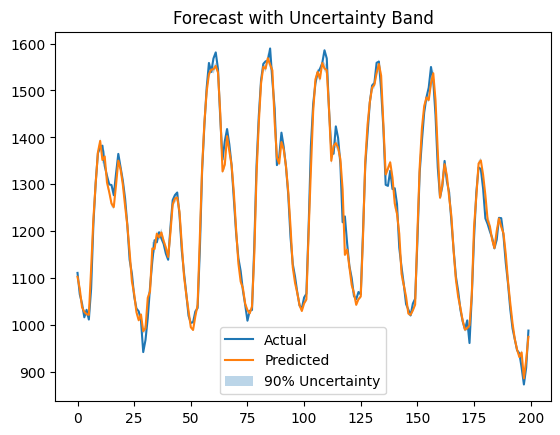

In [ ]:
#Plot uncertainty band:
plt.figure()
plt.plot(y_test.values[:200], label="Actual")
plt.plot(mean_pred[:200], label="Predicted")

plt.fill_between(
    range(200),
    lower[:200],
    upper[:200],
    alpha=0.3,
    label="90% Uncertainty"
)

plt.legend()
plt.title("Forecast with Uncertainty Band")
plt.show()

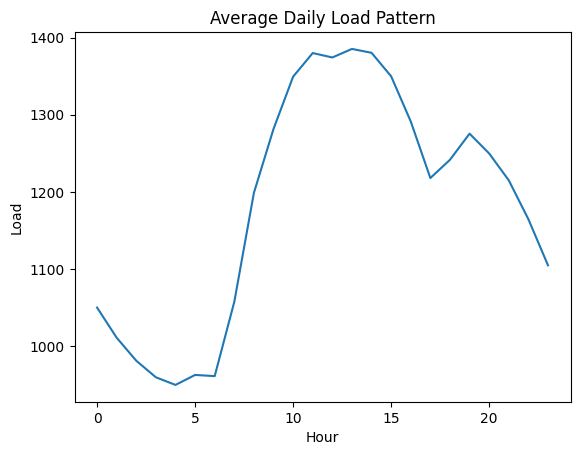

In [ ]:
#Seasonal Analysis
#Hourly pattern
hourly = df.groupby('hour')['nat_demand'].mean()

plt.figure()
plt.plot(hourly.index, hourly.values)
plt.title("Average Daily Load Pattern")
plt.xlabel("Hour")
plt.ylabel("Load")
plt.show()

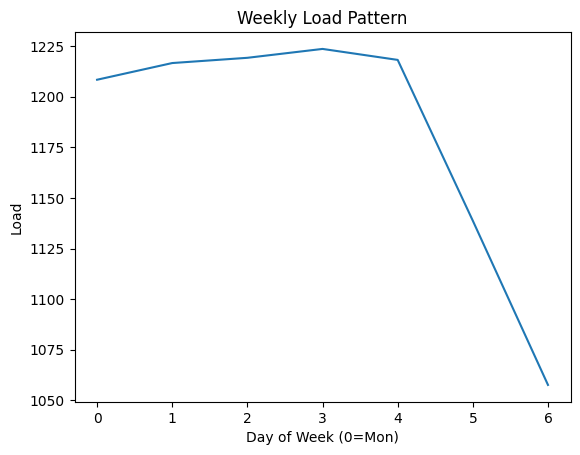

In [ ]:
#Weekly pattern
weekly = df.groupby('dayofweek')['nat_demand'].mean()

plt.figure()
plt.plot(weekly.index, weekly.values)
plt.title("Weekly Load Pattern")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Load")
plt.show()

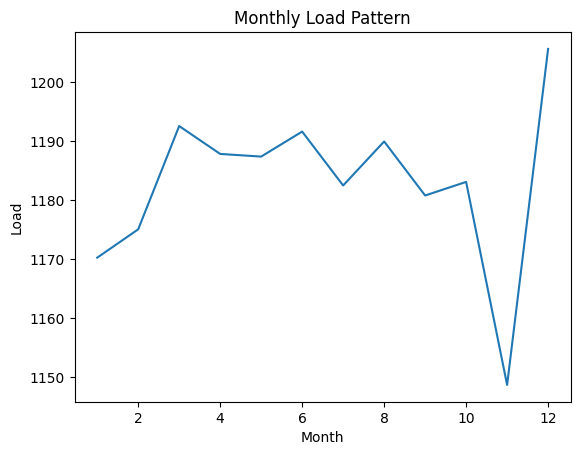

In [ ]:
#Monthly pattern
monthly = df.groupby('month')['nat_demand'].mean()

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Load Pattern")
plt.xlabel("Month")
plt.ylabel("Load")
plt.show()

In [ ]:
#Time Series Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_index, test_index in tscv.split(X):

    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train_cv, y_train_cv)
    pred = model.predict(X_test_cv)

    rmse = np.sqrt(mean_squared_error(y_test_cv, pred))
    rmse_scores.append(rmse)

print("RMSE per fold:", rmse_scores)
print("Mean RMSE:", np.mean(rmse_scores))
print("Std RMSE:", np.std(rmse_scores))

RMSE per fold: [np.float64(19.265906641647828), np.float64(26.626647676562303), np.float64(18.77119577617287), np.float64(28.636929891733306), np.float64(25.853434933451958)]
Mean RMSE: 23.830822983913652
Std RMSE: 4.035952108561925


In [ ]:
#Hyperparameter Tuning (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X, y)

print("Best Parameters:", random_search.best_params_)
print("Best RMSE:", -random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0}
Best RMSE: 25.215968125528445


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.9 MB/s eta 0:00:00


In [ ]:
#Optuna Optimization for XGBoost
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 0.5),
    }

    model = XGBRegressor(**params, random_state=42)

    tscv = TimeSeriesSplit(n_splits=3)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=tscv,
        scoring="neg_root_mean_squared_error"
    )

    return -scores.mean()


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-05-15 15:45:20,831] A new study created in memory with name: no-name-a1d8ceb9-ac09-4f97-ae38-19f2d26f04c0
[I 2026-05-15 15:45:55,295] Trial 0 finished with value: 24.629897138490445 and parameters: {'n_estimators': 574, 'max_depth': 4, 'learning_rate': 0.05633501402093705, 'subsample': 0.7684093321884837, 'colsample_bytree': 0.945726017892928, 'gamma': 0.2471039741469685}. Best is trial 0 with value: 24.629897138490445.
[I 2026-05-15 15:46:38,769] Trial 1 finished with value: 27.63961455479199 and parameters: {'n_estimators': 241, 'max_depth': 10, 'learning_rate': 0.09317888215907603, 'subsample': 0.9373326878352721, 'colsample_bytree': 0.9993865791946541, 'gamma': 0.16073875217728006}. Best is trial 0 with value: 24.629897138490445.
[I 2026-05-15 15:47:13,745] Trial 2 finished with value: 26.22082080212895 and parameters: {'n_estimators': 444, 'max_depth': 8, 'learning_rate': 0.02714154328777941, 'subsample': 0.9968010457904395, 'colsample_bytree': 0.8306334153188695, 'gamma':

Best Params: {'n_estimators': 574, 'max_depth': 4, 'learning_rate': 0.05633501402093705, 'subsample': 0.7684093321884837, 'colsample_bytree': 0.945726017892928, 'gamma': 0.2471039741469685}
Best RMSE: 24.629897138490445


In [ ]:
# Best parameters from Optuna
best_params = study.best_params

final_model = XGBRegressor(
    **best_params,
    random_state=42
)

# Train on full training data
final_model.fit(X_train, y_train)

print("✅ Final model trained successfully")

✅ Final model trained successfully


In [ ]:
y_pred = final_model.predict(X_test)

print("✅ Predictions completed")
print("Sample predictions:", y_pred[:5])

✅ Predictions completed
Sample predictions: [1110.4431 1084.6046 1040.2234 1031.3987 1026.5364]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n📊 FINAL MODEL PERFORMANCE")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("MAPE:", round(mape, 2), "%")


📊 FINAL MODEL PERFORMANCE
MAE : 18.244
RMSE: 24.78
MAPE: 1.52 %


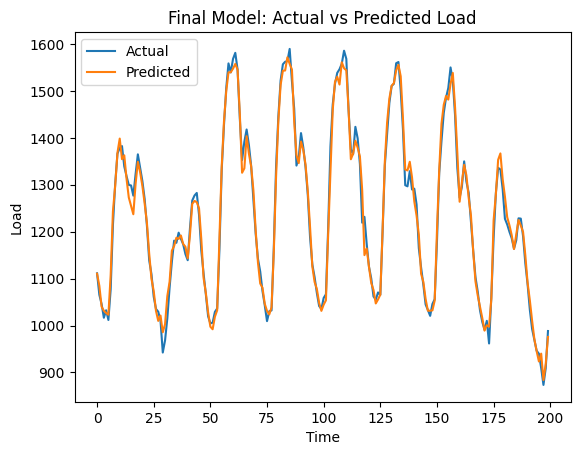

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.title("Final Model: Actual vs Predicted Load")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()
plt.show()

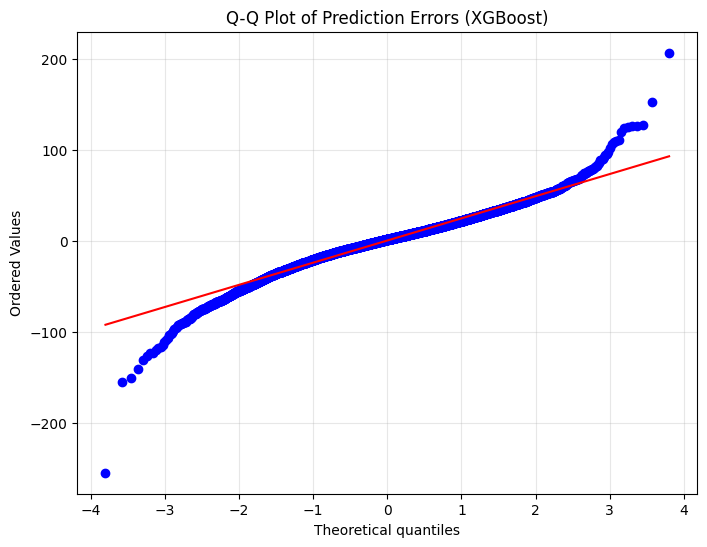

In [ ]:
import scipy.stats as stats

# ====================== 5. Q-Q Plot ======================
errors = y_test.values - y_pred

plt.figure(figsize=(8, 6))
stats.probplot(errors, dist="norm", plot=plt)
plt.title('Q-Q Plot of Prediction Errors (XGBoost)')
plt.grid(True, alpha=0.3)
plt.show()